# 03 - Model Training

Train a custom CNN on the processed brain tumor MRI dataset using on-the-fly normalization and augmentation, then evaluate it on the held-out test split.

## Workflow

1. Load `data/processed/Training` and `data/processed/Testing` with `image_dataset_from_directory`.
2. Split training into train and validation sets.
3. Apply `Rescaling(1./255)` in the model and training-only augmentation layers.
4. Build and train a custom CNN.
5. Evaluate with accuracy curves, confusion matrix, and classification report.

In [42]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

In [32]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Brain Tumor Detection and Classification using Deep Learning with Explainable AI (Grad-CAM)')
except ImportError:
    PROJECT_ROOT = None

In [43]:
def find_project_root(start=None):
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'processed' / 'Training').exists() and (candidate / 'data' / 'processed' / 'Testing').exists():
            return candidate
    raise FileNotFoundError('Could not locate data/processed/Training and data/processed/Testing.')

if PROJECT_ROOT is None:
    PROJECT_ROOT = find_project_root()

TRAIN_DIR = PROJECT_ROOT / 'data' / 'processed' / 'Training'
TEST_DIR = PROJECT_ROOT / 'data' / 'processed' / 'Testing'
MODELS_DIR = PROJECT_ROOT / 'models'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
CM_DIR = OUTPUTS_DIR / 'confusion_matrix'
GRAPH_DIR = OUTPUTS_DIR / 'graphs'
REPORT_DIR = OUTPUTS_DIR / 'reports'
for folder in [MODELS_DIR, CM_DIR, GRAPH_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.15

PROJECT_ROOT, TRAIN_DIR, TEST_DIR

(PosixPath('/Users/apple/Desktop/ml capstone/Brain Tumor Detection and Classification using Deep Learning with Explainable AI (Grad-CAM)'),
 PosixPath('/Users/apple/Desktop/ml capstone/Brain Tumor Detection and Classification using Deep Learning with Explainable AI (Grad-CAM)/data/processed/Training'),
 PosixPath('/Users/apple/Desktop/ml capstone/Brain Tumor Detection and Classification using Deep Learning with Explainable AI (Grad-CAM)/data/processed/Testing'))

In [44]:
train_all_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False,
)

class_names = train_all_ds.class_names
num_classes = len(class_names)

train_ds = train_all_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

class_names, num_classes

Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.


(['glioma', 'meningioma', 'notumor', 'pituitary'], 4)

In [45]:
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [46]:
import numpy as np

def label_counts(ds, class_names):
    counts = np.zeros(len(class_names), dtype=int)
    for _, labels in ds:
        for l in labels.numpy():
            counts[l] += 1
    return dict(zip(class_names, counts))

print("train:", label_counts(train_all_ds, class_names))
print("val:  ", label_counts(val_ds, class_names))

2026-07-11 11:17:40.758017: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


train: {'glioma': 1207, 'meningioma': 1194, 'notumor': 1172, 'pituitary': 1187}
val:   {'glioma': 193, 'meningioma': 206, 'notumor': 228, 'pituitary': 213}


2026-07-11 11:17:40.989316: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


/var/folders/gh/2f7t55xd4lx_76x21r934l340000gn/T/ipykernel_10004/3561529803.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), ax=axes[0], palette='viridis')
2026-07-11 11:17:44.169611: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
/var/folders/gh/2f7t55xd4lx_76x21r934l340000gn/T/ipykernel_10004/3561529803.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

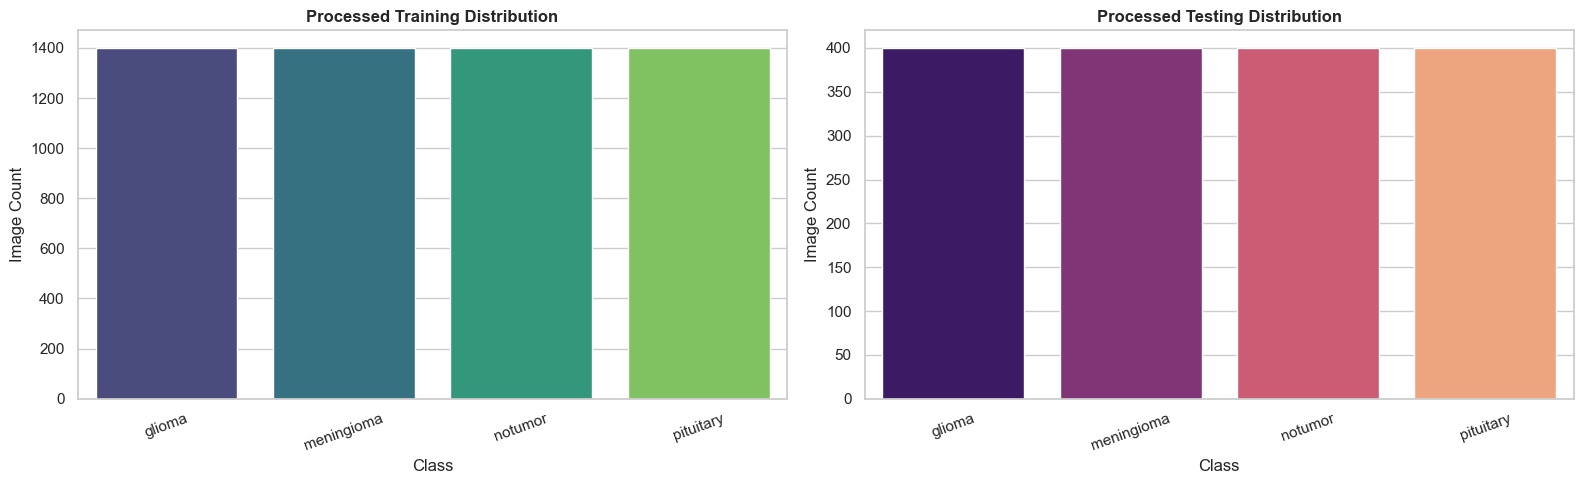

In [47]:
def count_images(split_dir):
    counts = {}
    for class_name in class_names:
        class_dir = Path(split_dir) / class_name
        counts[class_name] = sum(1 for p in class_dir.rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}) if class_dir.exists() else 0
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), ax=axes[0], palette='viridis')
axes[0].set_title('Processed Training Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Image Count')
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), ax=axes[1], palette='magma')
axes[1].set_title('Processed Testing Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Image Count')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

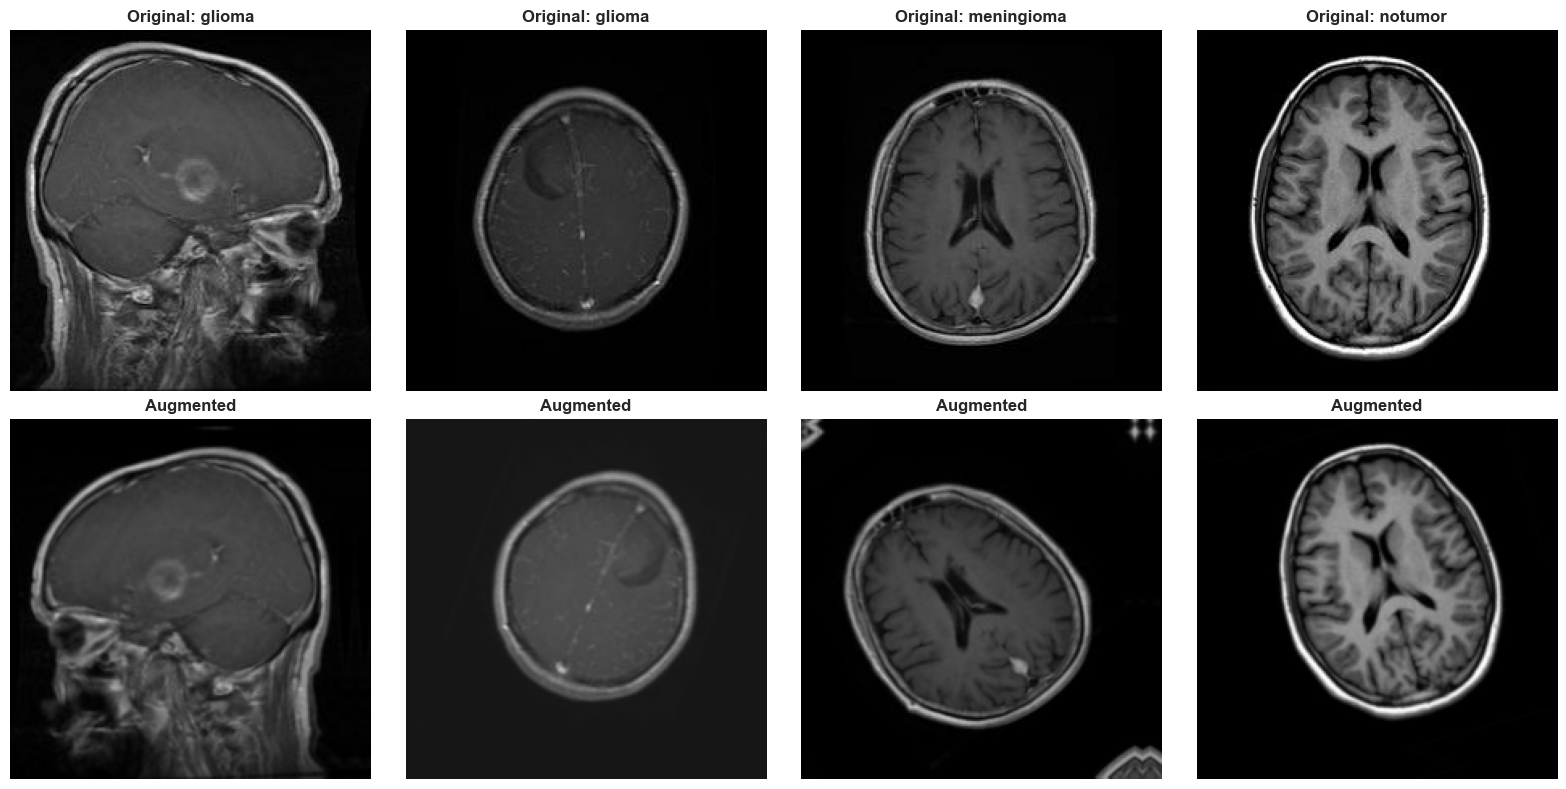

In [53]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.10, value_range=(0, 1)),
], name='augmentation')

def show_augmented_preview_scaled(dataset):
    images, labels = next(iter(dataset))
    images_scaled = images / 255.0
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for index in range(4):
        axes[0, index].imshow(images_scaled[index].numpy())
        axes[0, index].set_title(f'Original: {class_names[int(labels[index])]}')
        axes[0, index].axis('off')
        augmented = data_augmentation(images_scaled[index:index + 1], training=True)[0]
        axes[1, index].imshow(tf.clip_by_value(augmented, 0, 1).numpy())
        axes[1, index].set_title('Augmented')
        axes[1, index].axis('off')
    plt.tight_layout()
    plt.show()

show_augmented_preview_scaled(train_all_ds)

In [54]:
from tensorflow.keras import regularizers

L2_REG = 1e-4

def conv_block(x, filters, dropout_rate):
    x = layers.Conv2D(
        filters, 3, padding='same', use_bias=False,
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(
        filters, 3, padding='same', use_bias=False,
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = layers.Rescaling(1.0 / 255)(inputs)
x = data_augmentation(x)
x = conv_block(x, 32, 0.30)
x = conv_block(x, 64, 0.35)
x = conv_block(x, 128, 0.40)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
    128, activation='relu',
    kernel_regularizer=regularizers.l2(L2_REG)
)(x)
x = layers.Dropout(0.50)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs, name='custom_cnn')
model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,380 (1.16 MB)

 Trainable params: 304,484 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [56]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks,
)

model.save(MODELS_DIR / 'custom_cnn.keras')

Epoch 1/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4564 - loss: 1.2359
Epoch 1: val_loss improved from inf to 2.01384, saving model to /Users/apple/Desktop/ml capstone/Brain Tumor Detection and Classification using Deep Learning with Explainable AI (Grad-CAM)/models/best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 852s 6s/step - accuracy: 0.4568 - loss: 1.2353 - val_accuracy: 0.2298 - val_loss: 2.0138 - learning_rate: 1.0000e-04
Epoch 2/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6028 - loss: 1.0022
Epoch 2: val_loss did not improve from 2.01384
149/149 ━━━━━━━━━━━━━━━━━━━━ 850s 6s/step - accuracy: 0.6027 - loss: 1.0022 - val_accuracy: 0.2298 - val_loss: 2.6871 - learning_rate: 1.0000e-04
Epoch 3/40
  5/149 ━━━━━━━━━━━━━━━━━━━━ 11:56 5s/step - accuracy: 0.6185 - loss: 0.9658

KeyboardInterrupt: 

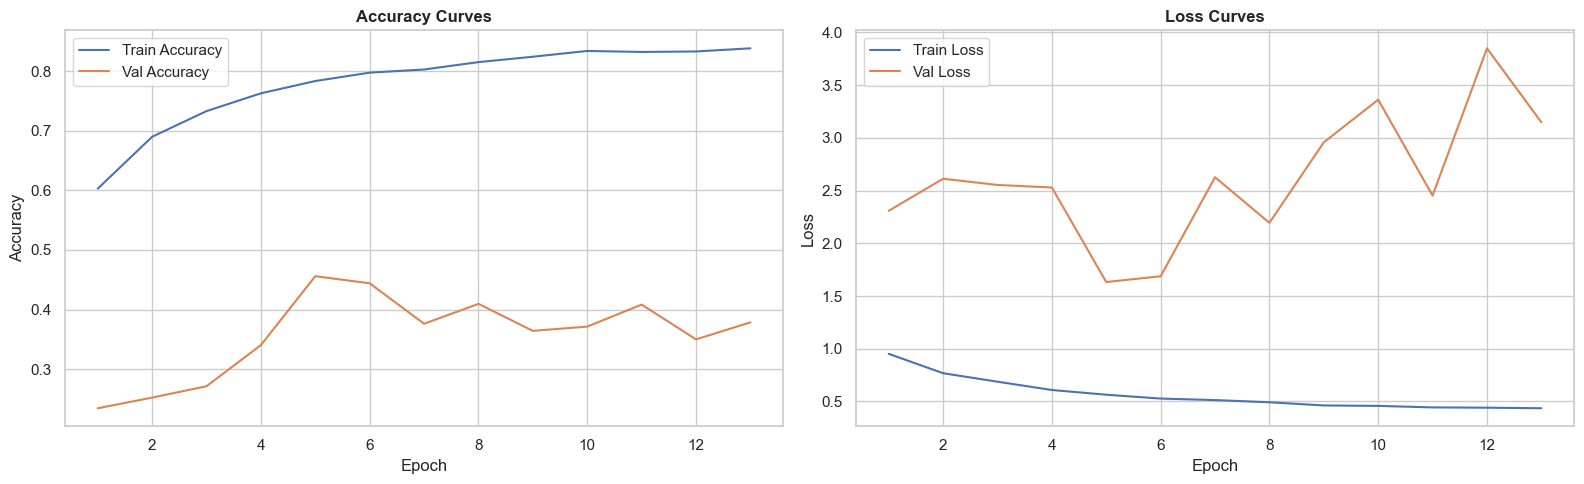

In [41]:
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(epochs, history_dict['accuracy'], label='Train Accuracy')
axes[0].plot(epochs, history_dict['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[1].plot(epochs, history_dict['loss'], label='Train Loss')
axes[1].plot(epochs, history_dict['val_loss'], label='Val Loss')
axes[1].set_title('Loss Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig(GRAPH_DIR / 'training_curves.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(CM_DIR / 'confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

with open(REPORT_DIR / 'classification_report.txt', 'w') as report_file:
    report_file.write(report)